In [26]:
attenuate <- function(p_true, accuracies) {
  p <- p_true
  for (acc in accuracies) {
    q <- acc / 100
    p <- p * q + (1 - p) * (1 - q)
  }
  p
}

get_pval <- function(n_mut1, n_mut2, n_sim = 2000) {
  n_mut <- n_mut1 + n_mut2
  dist <- rbinom(n_sim, n_mut, 0.5)
  diff_obs <- abs(n_mut1 - n_mut2)
  diff_null <- abs(2 * dist - n_mut)
  mean(diff_null >= diff_obs)
}

# ---- puissance : pour un N et un vrai diff donnes, avec l'accuracy du pipeline,
#      quelle fraction des experiences repetees donnerait un resultat significatif ? ----
power_for_diff <- function(n_mut, diff, accuracies, alpha = 0.05, n_sim_outer = 1000, n_sim_inner = 2000) {
  p_true <- 0.5 + diff / 2
  p_obs  <- attenuate(p_true, accuracies)

  n_mut1_obs <- rbinom(n_sim_outer, n_mut, p_obs)   # n_sim_outer jeux "observes" simules d'un coup
  n_mut2_obs <- n_mut - n_mut1_obs

  pvals <- mapply(function(m1, m2) get_pval(m1, m2, n_sim = n_sim_inner), n_mut1_obs, n_mut2_obs)

  mean(pvals < alpha)
}

# ---- plus petit vrai diff atteignant le seuil de puissance, pour un N donne ----
get_min_detectable_diff <- function(n_mut, diff_lvl, accuracies, threshold = 0.8, alpha = 0.05,
                                     n_sim_outer = 1000, n_sim_inner = 2000) {
  for (diff in sort(diff_lvl)) {
    pw <- power_for_diff(n_mut, diff, accuracies, alpha, n_sim_outer, n_sim_inner)
    if (pw >= threshold) return(diff * n_mut)
  }
  NA
}

In [37]:
n_mut <- 5273 + 5177
diff_lvl <- seq(0.005, 0.5, by = 0.005)
accuracies <- c(95.93, 96)   # remplace par tes vraies accuracies

min_diff <- get_min_detectable_diff(n_mut, diff_lvl, accuracies, threshold = 0.8)
min_diff              # ecart absolu minimal detectable
min_diff / n_mut       # ratio

[1] 365.75

[1] 0.035

In [28]:
# ---- grille de n_mut de 100 a 10000, et grille de diff testee ----
n_mut_range <- seq(100, 10000, by = 100)
diff_lvl <- seq(0.005, 0.5, by = 0.005)

curve_with_accuracy <- sapply(n_mut_range, function(n) {
  get_min_detectable_diff(n, diff_lvl, accuracies = c(95.93, 96), threshold = 0.95)
})

curve_perfect_accuracy <- sapply(n_mut_range, function(n) {
  get_min_detectable_diff(n, diff_lvl, accuracies = c(100, 100), threshold = 0.95)
})


Warning message:
"Using ragg device as default. Ignoring `type` and `antialias` arguments"


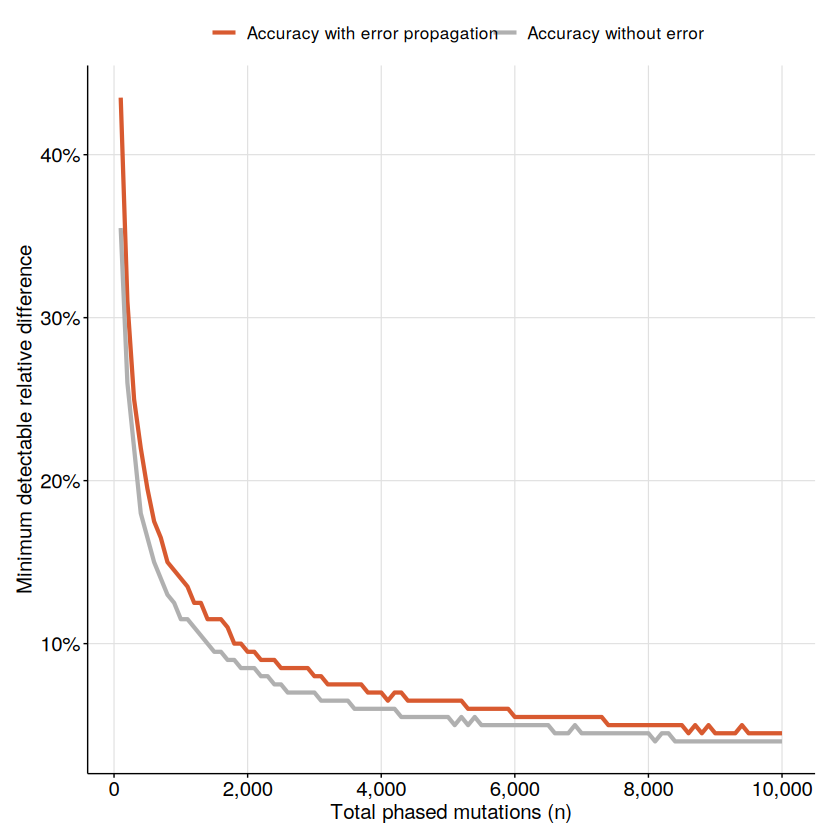

In [34]:
plot_df <- data.frame(
  n_mut = rep(n_mut_range, 2),
  effect_size = c(curve_with_accuracy, curve_perfect_accuracy),
  scenario = rep(c("Accuracy with error propagation", "Accuracy without error"), each = length(n_mut_range))
)
plot_df$relative_effect <- plot_df$effect_size / plot_df$n_mut

pal <- c("Accuracy with error propagation" = "#D85A30", "Accuracy without error" = "#B0B0B0")

p <- ggplot(plot_df, aes(x = n_mut, y = relative_effect, color = scenario)) +
  geom_line(linewidth = 0.9) +
  scale_color_manual(values = pal, name = NULL) +
  scale_x_continuous(breaks = seq(0, 10000, 2000), labels = scales::comma) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    x = "Total phased mutations (n)",
    y = "Minimum detectable relative difference"
  ) +
  guides(color = guide_legend(nrow = 2, byrow = TRUE,
                               override.aes = list(linewidth = 1.3))) +
  theme_minimal(base_size = 10) +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(linewidth = 0.25, color = "grey88"),
    axis.line = element_line(color = "black", linewidth = 0.3),
    axis.ticks = element_line(color = "black", linewidth = 0.3),
    axis.text = element_text(color = "black", size = 12),
    axis.title = element_text(size = 12),
    legend.position = "top",
    legend.justification = "left",
    legend.title = element_blank(),
    legend.text = element_text(size = 11),
    legend.key = element_blank(),
    legend.key.width = unit(0.9, "cm"),
    legend.key.height = unit(0.4, "cm"),
    legend.spacing.y = unit(0.05, "cm"),
    legend.margin = margin(0, 0, 5, 0),
    plot.margin = margin(10, 15, 5, 10)
  )
p

ggsave("/srv/home/mlef0011/Phasomix/output/figures/statistical_power_detection_threshold.png",
       p, width = 4.5, height = 5, dpi = 600, type = "cairo")

Warning message:
"Using ragg device as default. Ignoring `type` and `antialias` arguments"


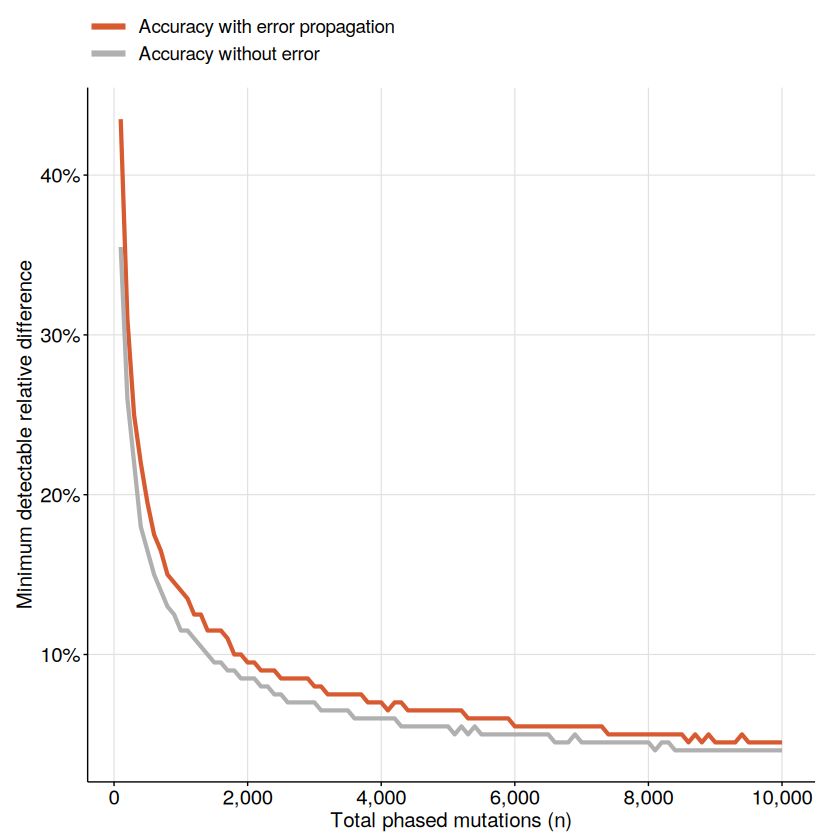